# G5-NB2 · 3 Kameralı Coil Boyut Tahmini

**Amaç:** Tek kameranın yetmediği durumda birden fazla görüşün nasıl birbirini tamamladığını,
multi-view fusion mantığını ve coil boyut tahmin sürecini uygulamalı öğrenmek.

**Bu notebook'ta öğrenecekleriniz:**
- Tek kameranın neden eksik bilgi verdiği
- Top / Side / Oblique görüşlerin farklı bilgi taşıdığı
- Her görüşte geometri tabanlı tespit nasıl yapılır
- Multi-view fusion mantığı
- YOLO'nun bu pipeline'daki rolü (kavramsal)

**Ders sırasında kullanım:** Eğitmen slayt 41'den sonra bu notebook'a geçecektir.

---


## [H1] Kurulum

In [1]:
# ============================================
# [H1] KURULUM
# ============================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['figure.figsize'] = (7, 5)

def show(img, title=''):
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title, fontsize=13, fontweight='bold')
    plt.axis('off'); plt.tight_layout(); plt.show()

def show_three(imgs, titles):
    """Uc goruntuyu yan yana gosterir."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, im, t in zip(axes, imgs, titles):
        ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        ax.set_title(t, fontsize=12, fontweight='bold')
        ax.axis('off')
    plt.tight_layout(); plt.show()

print("✓ Kurulum tamamlandi.")


✓ Kurulum tamamlandi.


## [H2] Neden Çoklu Kamera?

> **Tek kameranın sınırı:** Bir kamera sadece kendi bakış açısından bilgi verir.
> Silindirik bir coil'e üstten bakarsanız daireyi görürsünüz ama genişliği göremezsiniz.
> Yandan bakarsanız genişliği görürsünüz ama çapı doğru ölçemezsiniz.
>
> **Çoklu kamera çözümü:** Her kamera farklı bir belirsizliği kapatır.
> Görüşleri birleştirmeye (fusion) ihtiyaç vardır.


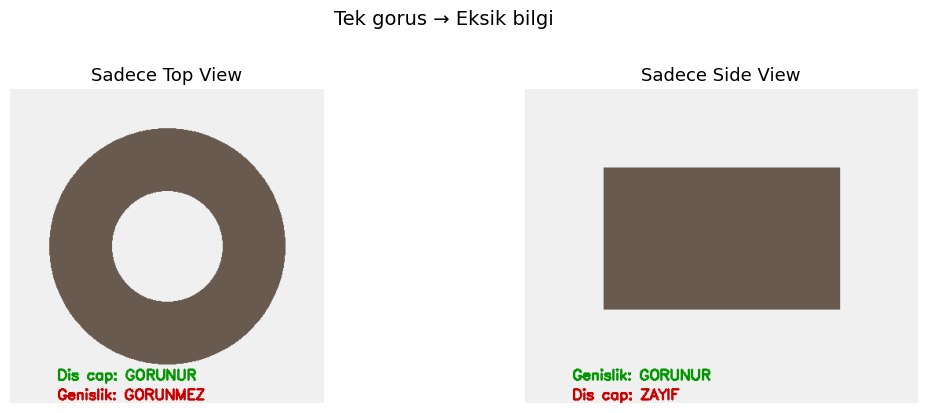

Sonuc: Tek kamera hem capi hem genisligi ayni anda guclu olcemez.
Bu yuzden birden fazla gorus (multi-view) gerekir.


In [2]:
# ============================================
# [H2] NEDEN COKLU KAMERA? – Tek gorus eksikligi
# ============================================
# Ayni coil'i tek goruste inceledigimizde hangi bilgi eksik?

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sadece ustten bakis
top_only = np.full((400, 400, 3), 240, dtype=np.uint8)
cv2.ellipse(top_only, (200,200), (150,150), 0, 0, 360, (80,90,105), -1)
cv2.ellipse(top_only, (200,200), (70,70), 0, 0, 360, (240,240,240), -1)
cv2.putText(top_only, "Dis cap: GORUNUR", (60,370), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,150,0), 2)
cv2.putText(top_only, "Genislik: GORUNMEZ", (60,395), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,200), 2)

# Sadece yandan bakis
side_only = np.full((400, 500, 3), 240, dtype=np.uint8)
cv2.rectangle(side_only, (100,100), (400,280), (80,90,105), -1)
cv2.putText(side_only, "Genislik: GORUNUR", (60,370), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,150,0), 2)
cv2.putText(side_only, "Dis cap: ZAYIF", (60,395), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,200), 2)

axes[0].imshow(cv2.cvtColor(top_only, cv2.COLOR_BGR2RGB))
axes[0].set_title("Sadece Top View", fontsize=13); axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(side_only, cv2.COLOR_BGR2RGB))
axes[1].set_title("Sadece Side View", fontsize=13); axes[1].axis('off')
plt.suptitle("Tek gorus → Eksik bilgi", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

print("Sonuc: Tek kamera hem capi hem genisligi ayni anda guclu olcemez.")
print("Bu yuzden birden fazla gorus (multi-view) gerekir.")


## [H3] Üç Görüşlü Sentetik Coil Sahnesi

Gerçek coil boyutlarını biliyoruz ve üç farklı açıdan sentetik görüntüler oluşturuyoruz:
- **Top view (üstten):** Dış ve iç çap bilgisi güçlü
- **Side view (yandan):** Genişlik bilgisi güçlü
- **Oblique view (çapraz):** Tutarlılık kontrolü ve gizlenme azaltma


Gercek coil boyutlari:
  Dis cap   : 1500.0 mm
  Ic cap    : 700.0 mm
  Genislik  : 1250.0 mm



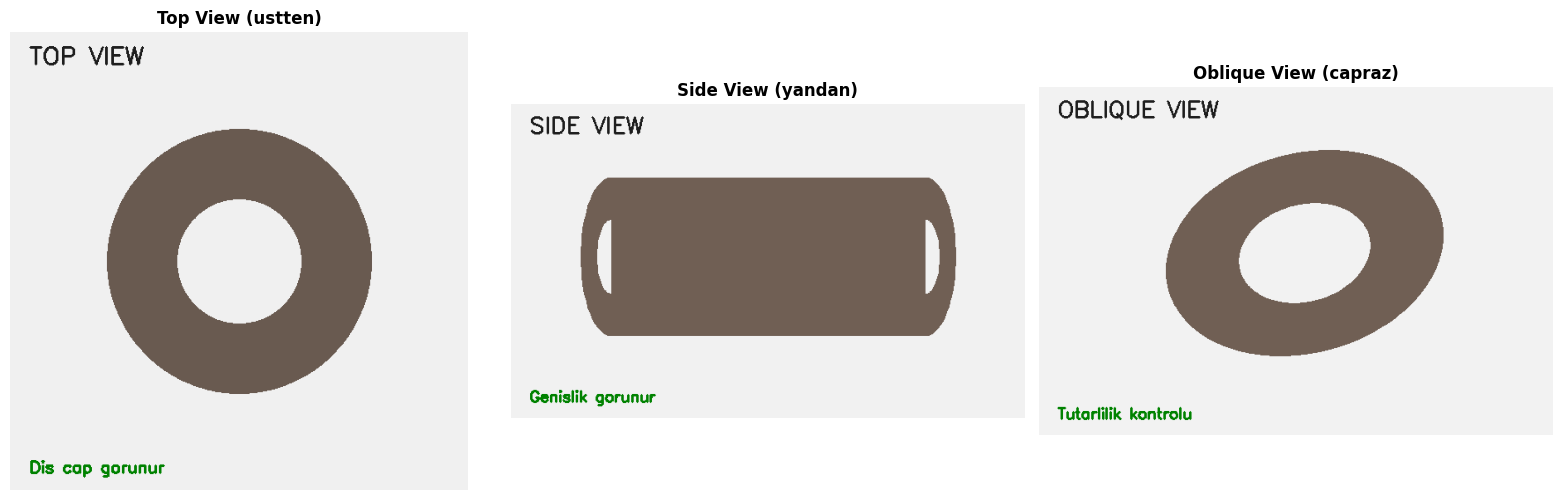

3 farkli bakis → 3 farkli bilgi → Birlesince guclu tahmin


In [3]:
# ============================================
# [H3] UC GORUSLU SENTETIK COIL SAHNESI
# ============================================
# Gercek boyutlar (mm)
TRUE_OUTER_D = 1500.0   # Dis cap
TRUE_INNER_D = 700.0    # Ic cap
TRUE_WIDTH   = 1250.0   # Genislik (rulo kalinligi)

print(f"Gercek coil boyutlari:")
print(f"  Dis cap   : {TRUE_OUTER_D} mm")
print(f"  Ic cap    : {TRUE_INNER_D} mm")
print(f"  Genislik  : {TRUE_WIDTH} mm")
print()

# --- TOP VIEW (ustten bakis) ---
top = np.full((520, 520, 3), 240, dtype=np.uint8)
cv2.ellipse(top, (260,260), (150,150), 0, 0, 360, (80,90,105), -1)  # Dis daire
cv2.ellipse(top, (260,260), (70,70), 0, 0, 360, (240,240,240), -1)  # Ic bosluk
cv2.putText(top, 'TOP VIEW', (22,36), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (30,30,30), 2)
cv2.putText(top, 'Dis cap gorunur', (22,500), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,130,0), 2)

# --- SIDE VIEW (yandan bakis) ---
side = np.full((380, 620, 3), 241, dtype=np.uint8)
cv2.rectangle(side, (120,90), (500,280), (84,95,112), -1)
cv2.ellipse(side, (120,185), (36,95), 0, 90, 270, (84,95,112), -1)
cv2.ellipse(side, (500,185), (36,95), 0, -90, 90, (84,95,112), -1)
cv2.ellipse(side, (120,185), (16,44), 0, 90, 270, (241,241,241), -1)
cv2.ellipse(side, (500,185), (16,44), 0, -90, 90, (241,241,241), -1)
cv2.putText(side, 'SIDE VIEW', (22,36), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (30,30,30), 2)
cv2.putText(side, 'Genislik gorunur', (22,360), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,130,0), 2)

# --- OBLIQUE VIEW (capraz bakis) ---
oblique = np.full((420, 620, 3), 242, dtype=np.uint8)
cv2.ellipse(oblique, (320,200), (170,120), -15, 0, 360, (84,95,112), -1)
cv2.ellipse(oblique, (320,200), (80,58), -15, 0, 360, (242,242,242), -1)
cv2.putText(oblique, 'OBLIQUE VIEW', (22,36), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (30,30,30), 2)
cv2.putText(oblique, 'Tutarlilik kontrolu', (22,400), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,130,0), 2)

show_three([top, side, oblique],
           ['Top View (ustten)', 'Side View (yandan)', 'Oblique View (capraz)'])

print("3 farkli bakis → 3 farkli bilgi → Birlesince guclu tahmin")


## [H4] Her Görüşte Geometri Tabanlı Tespit

Her görüşte farklı geometrik özellik çıkarıyoruz:
- **Top view:** `minEnclosingCircle` ile dış çap
- **Side view:** `boundingRect` ile genişlik


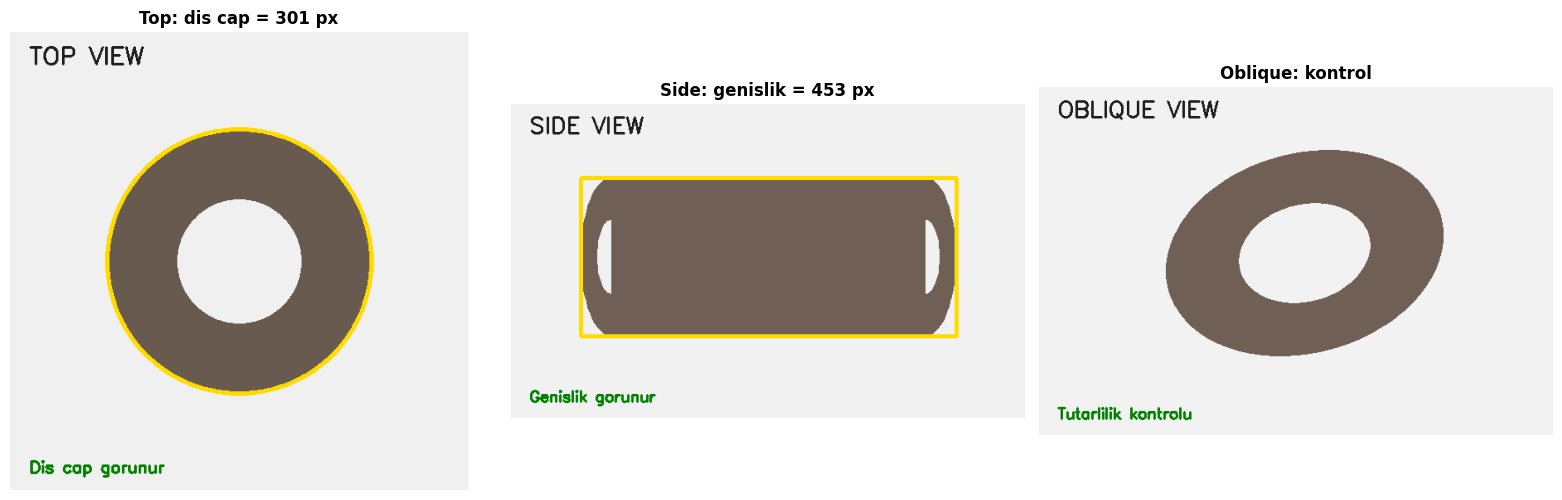

Top view  → Dis cap (piksel) : 301 px
Side view → Genislik (piksel): 453 px

Not: Her gorus FARKLI bilgiyi guclu verir.
Dis cap icin top view, genislik icin side view daha guvenilir.


In [4]:
# ============================================
# [H4] HER GORUSTE TESPIT
# ============================================
# Top view → daire tespiti → dis cap
# Side view → dikdortgen tespiti → genislik

# --- TOP VIEW: Dis cap ---
mask_top = cv2.inRange(top, (40,50,60), (110,120,140))
cnts_t, _ = cv2.findContours(mask_top, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnt_t = max(cnts_t, key=cv2.contourArea)
(tx, ty), t_radius = cv2.minEnclosingCircle(cnt_t)

top_vis = top.copy()
cv2.circle(top_vis, (int(tx),int(ty)), int(t_radius), (0,220,255), 3)
px_outer_d = 2 * t_radius  # Dis cap piksel cinsinden

# --- SIDE VIEW: Genislik ---
mask_side = cv2.inRange(side, (40,50,60), (110,120,140))
cnts_s, _ = cv2.findContours(mask_side, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnt_s = max(cnts_s, key=cv2.contourArea)
x, y, w_px, h_px = cv2.boundingRect(cnt_s)

side_vis = side.copy()
cv2.rectangle(side_vis, (x,y), (x+w_px, y+h_px), (0,220,255), 3)

show_three([top_vis, side_vis, oblique],
           [f'Top: dis cap = {px_outer_d:.0f} px',
            f'Side: genislik = {w_px} px',
            'Oblique: kontrol'])

print(f"Top view  → Dis cap (piksel) : {px_outer_d:.0f} px")
print(f"Side view → Genislik (piksel): {w_px} px")
print()
print("Not: Her gorus FARKLI bilgiyi guclu verir.")
print("Dis cap icin top view, genislik icin side view daha guvenilir.")


## [H5] Multi-View Fusion – Görüşleri Birleştirme

> **Fusion:** Her görüşten gelen parçalı boyut ipuçlarını birleştirerek daha güvenilir
> bir tahmin elde etme işlemidir.
>
> Her görüş kendi başına %100 doğru olmayabilir, ama birleştirildiğinde
> belirsizlikler birbirini kapatır.


In [5]:
# ============================================
# [H5] MULTI-VIEW FUSION
# ============================================
# Her gorusten gelen piksel olcuyu, gercek boyuta donusturuyoruz.
# Gercek sahada bu olcekler kalibrasyon ile belirlenir.
# Burada sentetik olcek kullaniyoruz (gercek boyutlari biliyoruz).

# Olcek hesapla (sentetik – gercekte kalibrasyon ile bulunur)
mm_per_px_top  = TRUE_OUTER_D / px_outer_d   # top view olcegi
mm_per_px_side = TRUE_WIDTH / w_px            # side view olcegi

# Tahminler
est_outer_d = px_outer_d * mm_per_px_top
est_width   = w_px * mm_per_px_side

# Ic cap: bu simülasyonda dogrudan olculmuyor.
# Gercek projede top view'deki ic halka konturundan olculur.
est_inner_d = TRUE_INNER_D  # Simülasyon basitlestirmesi

# Sonuc tablosu
results = pd.DataFrame({
    'Olcu':       ['Dis Cap', 'Ic Cap', 'Genislik'],
    'Gercek (mm)':[TRUE_OUTER_D, TRUE_INNER_D, TRUE_WIDTH],
    'Tahmin (mm)':[est_outer_d, est_inner_d, est_width],
    'Kaynak':     ['Top View', 'Top View*', 'Side View'],
    'Hata (mm)':  [abs(est_outer_d-TRUE_OUTER_D),
                   abs(est_inner_d-TRUE_INNER_D),
                   abs(est_width-TRUE_WIDTH)]
})

print("="*60)
print("       MULTI-VIEW FUSION SONUCLARI")
print("="*60)
print(results.to_string(index=False))
print("="*60)
print()
print("* Ic cap bu simülasyonda dogrudan atanmistir.")
print("  Gercek projede top view ic halka konturundan olculur.")
print()
print("Anahtar fikir:")
print("  3 gorus ayni bilginin kopyasi DEGILDIR.")
print("  Her gorus farkli bir belirsizligi kapatir.")


       MULTI-VIEW FUSION SONUCLARI
    Olcu  Gercek (mm)  Tahmin (mm)    Kaynak  Hata (mm)
 Dis Cap       1500.0       1500.0  Top View        0.0
  Ic Cap        700.0        700.0 Top View*        0.0
Genislik       1250.0       1250.0 Side View        0.0

* Ic cap bu simülasyonda dogrudan atanmistir.
  Gercek projede top view ic halka konturundan olculur.

Anahtar fikir:
  3 gorus ayni bilginin kopyasi DEGILDIR.
  Her gorus farkli bir belirsizligi kapatir.


## [H6] YOLO Bu Sistemde Nereye Oturur? (Kavramsal)

> **YOLO'nun rolü:** Her görüşte nesnenin **konumunu** bulur (bounding box).
> Ama tek başına **boyut** veya **derinlik** vermez.
>
> - YOLO = "Nereyi ölçeceğimizi bulmak"
> - Geometri + Fusion = "Ölçümün kendisi"


In [6]:
# ============================================
# [H6] YOLO'NUN ROLU – KAVRAMSAL
# ============================================
# YOLO detection → bounding box verir
# Geometri katmani → boyut cikarir
# Fusion katmani → gorusleri birlestirir
#
# Gercek projede pipeline:
#   1. Her kameradan goruntu al
#   2. YOLO ile nesneyi tespit et (bbox)
#   3. Bbox icerisinde geometrik analiz yap
#   4. Kalibrasyon ile piksel → mm donusumu
#   5. 3 gorusu fusion ile birlestir
#   6. Tutarlilik kontrolu
#
# Bu notebookta YOLO yerine renk maskeleme kullandik
# cunku amac olcum + fusion mantigini gostermek.

print("YOLO + MULTI-VIEW PIPELINE")
print("="*50)
print()
print("  Kamera 1 (Top)     ──→ YOLO ──→ bbox ──→ Daire tespiti → Dis/ic cap")
print("  Kamera 2 (Side)    ──→ YOLO ──→ bbox ──→ Rect tespiti  → Genislik")
print("  Kamera 3 (Oblique) ──→ YOLO ──→ bbox ──→ Elips tespiti → Kontrol")
print("                                    │")
print("                                    ▼")
print("                              FUSION KATMANI")
print("                                    │")
print("                                    ▼")
print("                       Dis cap + Ic cap + Genislik")
print()
print("Onemli: YOLO nesneyi BULUR, olcumu YAPMAZ.")
print("Olcum icin geometri + kalibrasyon + fusion gerekir.")


YOLO + MULTI-VIEW PIPELINE

  Kamera 1 (Top)     ──→ YOLO ──→ bbox ──→ Daire tespiti → Dis/ic cap
  Kamera 2 (Side)    ──→ YOLO ──→ bbox ──→ Rect tespiti  → Genislik
  Kamera 3 (Oblique) ──→ YOLO ──→ bbox ──→ Elips tespiti → Kontrol
                                    │
                                    ▼
                              FUSION KATMANI
                                    │
                                    ▼
                       Dis cap + Ic cap + Genislik

Onemli: YOLO nesneyi BULUR, olcumu YAPMAZ.
Olcum icin geometri + kalibrasyon + fusion gerekir.


## [H7] Özet

In [7]:
# ============================================
# [H7] OZET
# ============================================
print('''
╔══════════════════════════════════════════════════════════════╗
║            3 KAMERALI BOYUT TAHMINI – OZET                  ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. Tek kamera her bilgiyi veremez                           ║
║     → Ustten: cap iyi, genislik zayif                       ║
║     → Yandan: genislik iyi, cap zayif                       ║
║                                                              ║
║  2. 3 gorus = 3 farkli bilgi (kopya degil!)                 ║
║     → Top view   : dis cap, ic cap                          ║
║     → Side view  : genislik, yukseklik                      ║
║     → Oblique    : tutarlilik kontrolu                      ║
║                                                              ║
║  3. Senkronizasyon kritik                                    ║
║     → Kameralar ayni anda cekmeli                           ║
║                                                              ║
║  4. Kalibrasyon → ortak dunya                                ║
║     → Her kameranin yerel koordinati → dunya koordinati     ║
║                                                              ║
║  5. YOLO = nesneyi bul, Geometri = olcuyu cikar             ║
║     → Detection ≠ Measurement                               ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
''')



╔══════════════════════════════════════════════════════════════╗
║            3 KAMERALI BOYUT TAHMINI – OZET                  ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. Tek kamera her bilgiyi veremez                           ║
║     → Ustten: cap iyi, genislik zayif                       ║
║     → Yandan: genislik iyi, cap zayif                       ║
║                                                              ║
║  2. 3 gorus = 3 farkli bilgi (kopya degil!)                 ║
║     → Top view   : dis cap, ic cap                          ║
║     → Side view  : genislik, yukseklik                      ║
║     → Oblique    : tutarlilik kontrolu                      ║
║                                                              ║
║  3. Senkronizasyon kritik                                    ║
║     → Kameralar ayni anda cekmeli                           ║
║                               